# Day 03  Độ ổn định và leakage

[Open in Colab](https://colab.research.google.com/github/ketnoimaytinh797-dotcom/EGFR-Radiomics-MiniBootcamp/blob/main/book/day03.ipynb)

[Slide của buổi này](_static/slides/day03_slides.pptx)

## Mục tiêu bài học

- Tính AUC theo 5 fold cross validation
- Tính bootstrap CI cho AUC
- Thấy được vì sao leakage làm kết quả đẹp giả
- Viết câu kết luận thận trọng hơn

## Nội dung

Buổi này trả lời câu hỏi khó nhất khi đọc báo cáo:

Con số AUC có bền hay không

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

GITHUB_USER = "ketnoimaytinh797-dotcom"
REPO_NAME = "EGFR-Radiomics-MiniBootcamp"
BRANCH = "main"

def read_csv_demo(filename):
    local_candidates = [
        Path("data") / filename,
        Path("../data") / filename,
        Path(filename),
    ]
    for path in local_candidates:
        if path.exists():
            return pd.read_csv(path)
    url = f"https://raw.githubusercontent.com/{GITHUB_USER}/{REPO_NAME}/{BRANCH}/data/{filename}"
    return pd.read_csv(url)


In [2]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

plt.rcParams["figure.dpi"] = 160
df = read_csv_demo("nsclc_egfr_radiomics_simplified.csv")
output_dir = Path("outputs/day03")
output_dir.mkdir(parents=True, exist_ok=True)


## Bước 1  Chuẩn bị ring1 để kiểm tra độ ổn định


In [3]:
clinical_cols = ["age", "sex", "smoking_status", "histology", "stage", "tumor_size_mm", "tumor_volume_cm3", "tp53_mutation"]
ring1_cols = clinical_cols + [c for c in df.columns if c.startswith("ring1_")]

def make_pipe(X):
    cat = [c for c in X.columns if X[c].dtype == "object"]
    num = [c for c in X.columns if c not in cat]

    pre = ColumnTransformer([
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]), num),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat),
    ])

    return Pipeline([
        ("pre", pre),
        ("model", LogisticRegression(max_iter=1000))
    ])

X = df[ring1_cols].copy()
y = df["egfr_mutation"].astype(int)
pipe = make_pipe(X)


## Bước 2  Tính 5 fold cross validation


In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")

cv_table = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "AUC": np.round(cv_scores, 3)
})
cv_table.to_csv(output_dir / "cv_auc_table.csv", index=False)
cv_table


,Fold,AUC
0,1,0.747
1,2,0.833
2,3,0.785
3,4,0.778
4,5,0.909


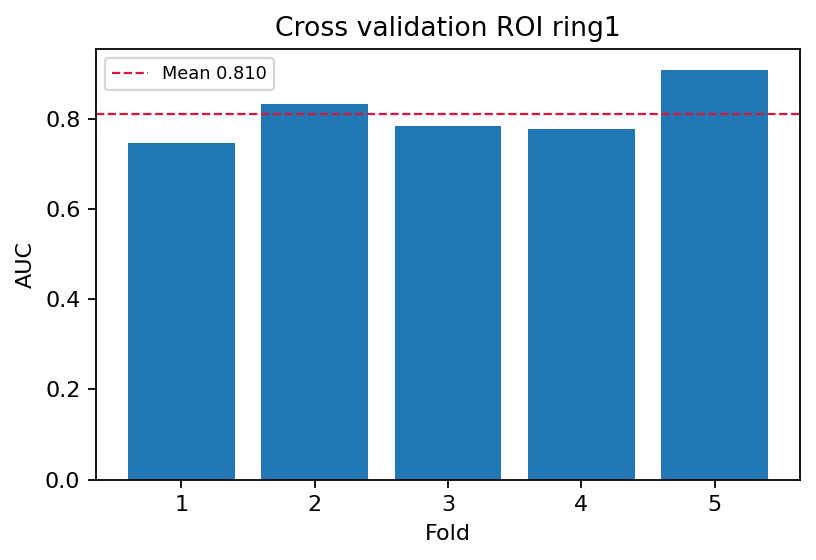

In [5]:
fig, ax = plt.subplots(figsize=(5.2, 3.6))
ax.bar([1, 2, 3, 4, 5], cv_scores)
ax.axhline(cv_scores.mean(), color="crimson", linestyle="--", linewidth=1, label=f"Mean {cv_scores.mean():.3f}")
ax.set_title("Cross validation ROI ring1")
ax.set_xlabel("Fold")
ax.set_ylabel("AUC")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(output_dir / "cv_auc_bar.png")
plt.show()


### Cách đọc kết quả

Nếu 5 fold không chênh nhau quá mạnh thì mô hình ổn hơn.  
Ở bộ demo này mean AUC của 5 fold vào khoảng 0.810.


## Bước 3  Tính bootstrap CI cho AUC


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
pipe.fit(X_train, y_train)
prob = pipe.predict_proba(X_test)[:, 1]

rng = np.random.default_rng(42)
boot_aucs = []
y_test_reset = y_test.reset_index(drop=True)

for _ in range(2000):
    idx = rng.integers(0, len(y_test_reset), len(y_test_reset))
    y_boot = y_test_reset.iloc[idx]
    p_boot = prob[idx]
    if y_boot.nunique() < 2:
        continue
    boot_aucs.append(roc_auc_score(y_boot, p_boot))

boot = np.array(boot_aucs)
ci_low, ci_high = np.quantile(boot, [0.025, 0.975])

pd.DataFrame({"bootstrap_auc": boot}).to_csv(output_dir / "bootstrap_auc_values.csv", index=False)
ci_low, ci_high


(np.float64(0.6859903381642513), np.float64(0.9246794871794871))

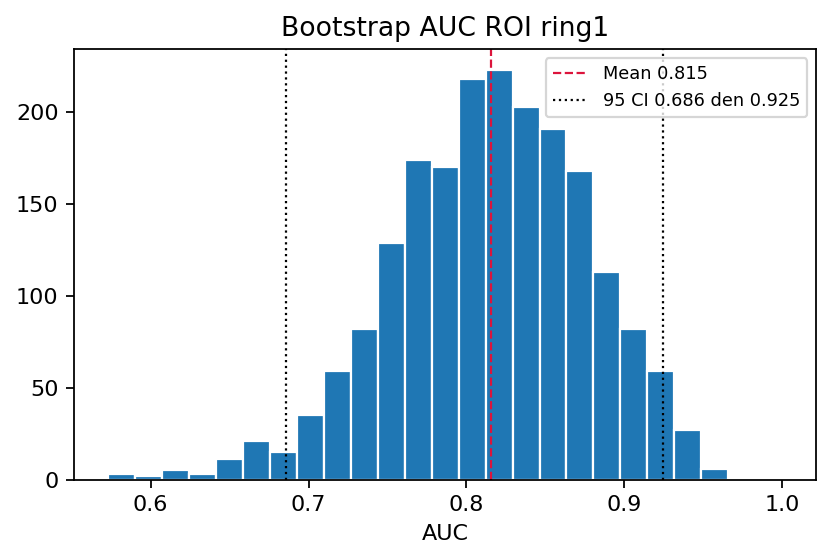

In [7]:
fig, ax = plt.subplots(figsize=(5.3, 3.6))
ax.hist(boot, bins=25, edgecolor="white")
ax.axvline(boot.mean(), color="crimson", linestyle="--", linewidth=1, label=f"Mean {boot.mean():.3f}")
ax.axvline(ci_low, color="black", linestyle=":", linewidth=1)
ax.axvline(ci_high, color="black", linestyle=":", linewidth=1, label=f"95 CI {ci_low:.3f} den {ci_high:.3f}")
ax.set_title("Bootstrap AUC ROI ring1")
ax.set_xlabel("AUC")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(output_dir / "bootstrap_auc_hist.png")
plt.show()


## Bước 4  Làm một ví dụ leakage rất đơn giản

Ví dụ này cố ý scale trước rồi mới cross validation.  
Cách làm đó làm một phần thông tin của toàn bộ tập dữ liệu đi vào trước khi chia fold.


In [8]:
X_num = df[[c for c in df.columns if c.startswith("ring1_")]].copy()

X_bad = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X_num), columns=X_num.columns)
X_bad = pd.DataFrame(StandardScaler().fit_transform(X_bad), columns=X_bad.columns)

bad_scores = cross_val_score(
    LogisticRegression(max_iter=1000),
    X_bad,
    y,
    cv=cv,
    scoring="roc_auc"
)

leakage_demo = pd.DataFrame({
    "Cach tinh": ["Dung pipeline trong CV", "Scale truoc roi moi CV"],
    "Mean AUC": [round(cv_scores.mean(), 3), round(bad_scores.mean(), 3)]
})
leakage_demo.to_csv(output_dir / "leakage_demo.csv", index=False)
leakage_demo


,Cach tinh,Mean AUC
0,Dung pipeline trong CV,0.810
1,Scale truoc roi moi CV,0.774


## Bước 5  Viết ngắn kết luận của buổi 3


In [9]:
summary_day03 = (
    f"ROI ring1 co mean AUC cua 5 fold la {cv_scores.mean():.3f}. "
    f"Bootstrap 95 CI nam trong khoang {ci_low:.3f} den {ci_high:.3f}. "
    f"Vi vay ket qua khong nen doc chi bang mot con so AUC duy nhat."
)
summary_day03


'ROI ring1 co mean AUC cua 5 fold la 0.810. Bootstrap 95 CI nam trong khoang 0.686 den 0.925. Vi vay ket qua khong nen doc chi bang mot con so AUC duy nhat.'

## Tự kiểm tra

- Có hiểu cross validation khác train test split ở đâu chưa
- Có hiểu bootstrap CI dùng để làm gì chưa
- Có hiểu leakage là gì chưa
- Có hiểu vì sao phải giữ preprocessing trong pipeline chưa
